# Laboratorio de Pandas Avanzado
## Fase 1: Ingeniería de Datos Temporales

**Bootcamp Python para Ciencia de Datos — PY4**  
**Módulo 1: Python y Manipulación de Datos**

---

### Contexto

Trabajamos con datos reales de **Divvy**, el sistema de bicicletas compartidas de Chicago operado por Lyft. Es uno de los sistemas de bikeshare más grandes de América del Norte, con más de 1,000 estaciones y 6.6 millones de viajes registrados en 2024.

Divvy publica mensualmente sus datos de viajes de forma gratuita. Cada archivo contiene cientos de miles de registros con timestamps exactos y coordenadas geográficas — exactamente lo que necesitamos para practicar análisis temporal y geoespacial con datos del mundo real.

**Dataset:** `202401-divvy-tripdata.csv` — Enero 2024  
**Fuente:** https://divvybikes.com/system-data  
**Licencia:** Divvy Data License Agreement (uso libre con atribución)

En esta sesión vamos a:
1. Descargar y cargar el archivo directamente desde la fuente.
2. Explorar la estructura del dataset real.
3. Convertir columnas de texto a formato `datetime`.
4. Calcular duración de viajes como nueva variable.
5. Usar el tiempo como índice para habilitar series temporales.
6. Aplicar *resampling* para detectar tendencias.
7. Manejar zonas horarias.

---

## 0. Preparación del entorno

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import urllib.request
import zipfile
import io
import os

print("Librerias cargadas")
print(f"pandas version: {pd.__version__}")

Librerias cargadas
pandas version: 2.2.2


## 1. Descarga del dataset real

Divvy publica sus datos en un bucket S3 público. Los archivos están organizados por mes con el formato `YYYYMM-divvy-tripdata.zip`. Vamos a descargar enero 2024, que tiene alrededor de 140,000 viajes — suficiente para el análisis pero manejable en una laptop.

La celda siguiente descarga el ZIP, lo descomprime en memoria, y carga el CSV directamente en un DataFrame sin necesidad de guardar nada en disco.

In [2]:
ARCHIVO_LOCAL = '202401-divvy-tripdata.csv'
URL = 'https://divvy-tripdata.s3.amazonaws.com/202401-divvy-tripdata.zip'

if os.path.exists(ARCHIVO_LOCAL):
    print("Archivo ya descargado. Cargando desde disco...")
    df_raw = pd.read_csv(ARCHIVO_LOCAL)
else:
    print(f"Descargando desde: {URL}")
    req = urllib.request.Request(URL, headers={'User-Agent': 'Mozilla/5.0'})
    with urllib.request.urlopen(req) as response:
        contenido = response.read()
    print(f"Descargado: {len(contenido)/1e6:.1f} MB")

    with zipfile.ZipFile(io.BytesIO(contenido)) as z:
        nombre_csv = z.namelist()[0]
        print(f"Archivo dentro del ZIP: {nombre_csv}")
        with z.open(nombre_csv) as f:
            df_raw = pd.read_csv(f)
    df_raw.to_csv(ARCHIVO_LOCAL, index=False)
    print("Guardado en disco para futuras ejecuciones.")

print(f"\nDataset cargado: {df_raw.shape[0]:,} filas, {df_raw.shape[1]} columnas")

Descargando desde: https://divvy-tripdata.s3.amazonaws.com/202401-divvy-tripdata.zip
Descargado: 5.5 MB
Archivo dentro del ZIP: 202401-divvy-tripdata.csv
Guardado en disco para futuras ejecuciones.

Dataset cargado: 144,873 filas, 13 columnas


## 2. Exploración inicial

Antes de transformar nada, siempre hay que entender qué tenemos. Con datos reales esto es especialmente importante: columnas que parecen numéricas pueden ser texto, y los valores nulos suelen estar en lugares inesperados.

In [3]:
# Primeras filas
df_raw.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,C1D650626C8C899A,electric_bike,2024-01-12 15:30:27,2024-01-12 15:37:59,Wells St & Elm St,KA1504000135,Kingsbury St & Kinzie St,KA1503000043,41.903267,-87.634737,41.889177,-87.638506,member
1,EECD38BDB25BFCB0,electric_bike,2024-01-08 15:45:46,2024-01-08 15:52:59,Wells St & Elm St,KA1504000135,Kingsbury St & Kinzie St,KA1503000043,41.902937,-87.634440,41.889177,-87.638506,member
2,F4A9CE78061F17F7,electric_bike,2024-01-27 12:27:19,2024-01-27 12:35:19,Wells St & Elm St,KA1504000135,Kingsbury St & Kinzie St,KA1503000043,41.902951,-87.634470,41.889177,-87.638506,member
3,0A0D9E15EE50B171,classic_bike,2024-01-29 16:26:17,2024-01-29 16:56:06,Wells St & Randolph St,TA1305000030,Larrabee St & Webster Ave,13193,41.884295,-87.633963,41.921822,-87.644140,member
4,33FFC9805E3EFF9A,classic_bike,2024-01-31 05:43:23,2024-01-31 06:09:35,Lincoln Ave & Waveland Ave,13253,Kingsbury St & Kinzie St,KA1503000043,41.948797,-87.675278,41.889177,-87.638506,member


In [4]:
# Tipos de datos y valores nulos
# (siempre es buena practica de chekear valores nullos en un dataset nuevo)

print("Tipos de datos:")
print(df_raw.dtypes)
print()
print("Valores nulos por columna:")
nulos = df_raw.isnull().sum()
print(nulos[nulos > 0])

Tipos de datos:
ride_id                object
rideable_type          object
started_at             object
ended_at               object
start_station_name     object
start_station_id       object
end_station_name       object
end_station_id         object
start_lat             float64
start_lng             float64
end_lat               float64
end_lng               float64
member_casual          object
dtype: object

Valores nulos por columna:
start_station_name    19165
start_station_id      19165
end_station_name      20749
end_station_id        20749
end_lat                 288
end_lng                 288
dtype: int64


In [5]:
# Valores únicos en columnas categóricas
print("Tipos de bicicleta (rideable_type):")
print(df_raw['rideable_type'].value_counts()) # check el numero de observaciones en cada categoria
print()
print("Tipo de usuario (member_casual):")
print(df_raw['member_casual'].value_counts())

Tipos de bicicleta (rideable_type):
rideable_type
classic_bike     76525
electric_bike    68348
Name: count, dtype: int64

Tipo de usuario (member_casual):
member_casual
member    120413
casual     24460
Name: count, dtype: int64


Observaciones importantes:
- `started_at` y `ended_at` aparecen como `object` (texto). Hay que convertirlos a `datetime`.
- `start_station_name` y `end_station_name` tienen bastantes valores nulos — esto es conocido en este dataset, ocurre principalmente en bicicletas eléctricas que se devuelven fuera de una estación.
- Tenemos coordenadas exactas en `start_lat`, `start_lng` (las usaremos en la Fase 2).

## 3. Conversión de fechas a `datetime`

Las columnas `started_at` y `ended_at` contienen timestamps en formato `YYYY-MM-DD HH:MM:SS`, pero Pandas las leyó como texto. Vamos a convertirlas.

Usamos `errors='coerce'` por buena práctica: si algún valor tiene un formato inesperado, lo convierte a `NaT` en lugar de romper todo.

Como sabemos exactamente el formato del dataset Divvy, podemos especificarlo con `format=` para que la conversión sea más rápida.

In [6]:
df = df_raw.copy() # buena practica de quedar el raw dataset separado

# Convertir ambas columnas de timestamps
df['started_at'] = pd.to_datetime(df['started_at'], format='%Y-%m-%d %H:%M:%S', errors='coerce')
df['ended_at']   = pd.to_datetime(df['ended_at'],   format='%Y-%m-%d %H:%M:%S', errors='coerce')
## Podemos omitir "format=", y Panda intentará inferir el formato automáticamente. Eso es más lento que especificar el formato explícitamente.

print("Tipos despues de la conversion:")
print(df[['started_at', 'ended_at']].dtypes)
print()
print(f"NaT en started_at: {df['started_at'].isnull().sum()}") # check valores nullos
print(f"NaT en ended_at:   {df['ended_at'].isnull().sum()}")

Tipos despues de la conversion:
started_at    datetime64[ns]
ended_at      datetime64[ns]
dtype: object

NaT en started_at: 0
NaT en ended_at:   0


## 4. Calcular duración del viaje

Una de las ventajas de tener fechas en formato `datetime` es que podemos hacer aritmética con ellas directamente. La diferencia entre dos timestamps nos da un objeto `Timedelta`.

Vamos a crear una columna `duracion_min` que represente cuántos minutos duró cada viaje.

In [7]:
# Calcular duración en minutos
df['duracion_min'] = (df['ended_at'] - df['started_at']).dt.total_seconds() / 60 # .dt.total_seconds() lo convierte a segundos

print("Estadísticas de duración (minutos):")
print(df['duracion_min'].describe().round(2)) # estadísticas descriptivas de la duración de los viajes, y round to 2 decimals

Estadísticas de duración (minutos):
count    144873.00
mean         15.06
std          80.63
min         -43.62
25%           4.43
50%           7.23
75%          11.98
max        1499.95
Name: duracion_min, dtype: float64


In [8]:
# Hay viajes con duración negativa o cero: datos incorrectos
print(f"Viajes con duracion <= 0: {(df['duracion_min'] <= 0).sum()}")
print(f"Viajes con duracion > 24 horas: {(df['duracion_min'] > (24*60)).sum()}")

# Filtrar: solo viajes entre 1 y 180 minutos (rango razonable para bikeshare)
df = df[(df['duracion_min'] > 1) & (df['duracion_min'] <= 180)].copy() # elimina viajes demasiado cortos (≤ 1 min) y elimina viajes excesivamente largos (> 180 min)
print(f"\nViajes válidos restantes: {len(df):,}")

Viajes con duracion <= 0: 97
Viajes con duracion > 24 horas: 329

Viajes válidos restantes: 139,704


## 5. Extracción de componentes temporales

Con las columnas ya en formato `datetime`, podemos extraer partes individuales usando el accessor `.dt`. Esto nos da variables nuevas que son muy útiles para análisis exploratorio.

In [9]:
# Extraer componentes de la fecha de inicio
df['hora']       = df['started_at'].dt.hour                    # Hora en que comenzó el viaje
df['dia_semana'] = df['started_at'].dt.day_name()             # Día de la semana del viaje
df['semana']     = df['started_at'].dt.isocalendar().week.astype(int)  # Semana calendario del año

print("Componentes extraídos. Primeras filas:")
df[['started_at', 'hora', 'dia_semana', 'semana', 'duracion_min']].head(6)

Componentes extraídos. Primeras filas:


,started_at,hora,dia_semana,semana,duracion_min
0,2024-01-12 15:30:27,15,Friday,2,7.533333
1,2024-01-08 15:45:46,15,Monday,2,7.216667
2,2024-01-27 12:27:19,12,Saturday,4,8.000000
3,2024-01-29 16:26:17,16,Monday,5,29.816667
4,2024-01-31 05:43:23,5,Wednesday,5,26.200000
5,2024-01-07 11:21:24,11,Sunday,1,8.650000


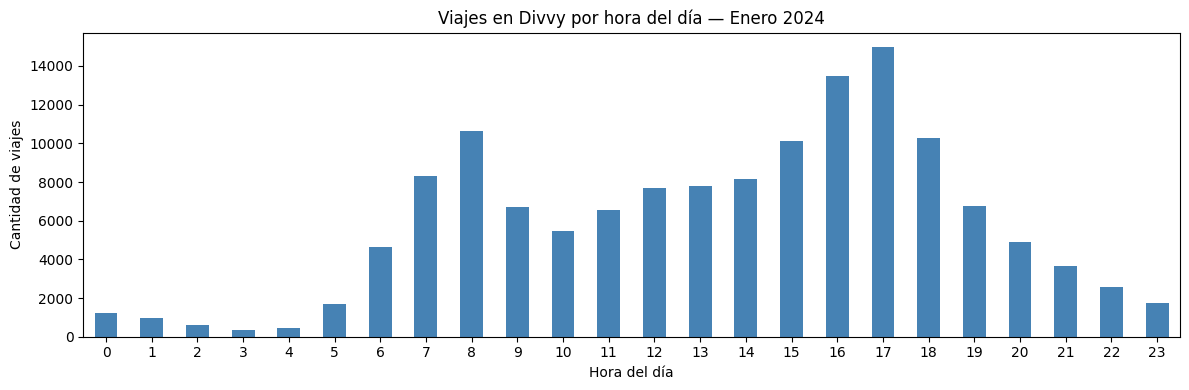

In [10]:
# ¿A qué hora se hacen más viajes? (creamos un grafico)

# Cuenta cuántos viajes comienzan en cada hora del día (0–23)
viajes_por_hora = df.groupby('hora').size()

# Crea la figura y los ejes del gráfico
fig, ax = plt.subplots(figsize=(12, 4))

# Grafica la cantidad de viajes por hora como barras
viajes_por_hora.plot(
    kind='bar',
    ax=ax,
    color='steelblue'
)

# Personaliza el gráfico
ax.set_title('Viajes en Divvy por hora del día — Enero 2024')
ax.set_xlabel('Hora del día')
ax.set_ylabel('Cantidad de viajes')

# Mantiene las etiquetas del eje X horizontales
ax.tick_params(axis='x', rotation=0)

# Ajusta automáticamente los márgenes y espacios
plt.tight_layout()

# Muestra el gráfico
plt.show()

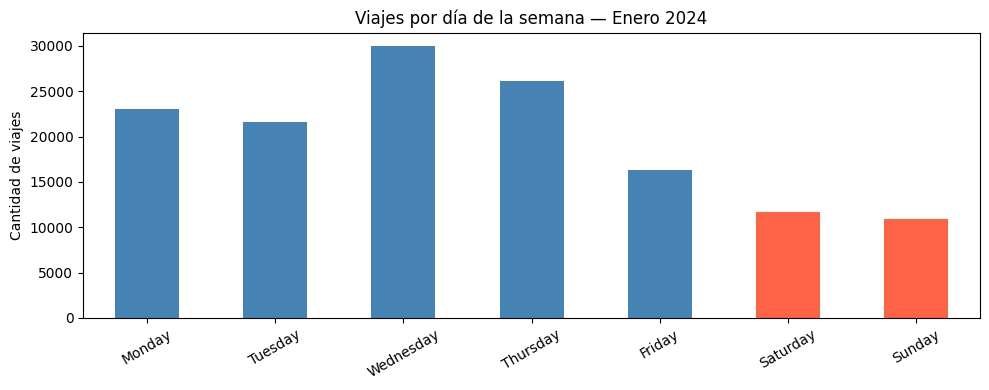

In [11]:
# ¿Qué días de la semana tienen más actividad? (creamos un grafico)

# Define el orden cronológico de los días de la semana
orden_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Cuenta los viajes por día y los organiza en el orden correcto
viajes_por_dia = df.groupby('dia_semana').size().reindex(orden_dias)

# Crea la figura y los ejes del gráfico
fig, ax = plt.subplots(figsize=(10, 4))

# Aplica rojo (tomato) a los fines de semana y azul (steelblue) a los días hábiles
colores = ['tomato' if d in ['Saturday', 'Sunday'] else 'steelblue' for d in orden_dias]

# Grafica los datos como barras aplicando los colores configurados
viajes_por_dia.plot(kind='bar', ax=ax, color=colores)

# Personaliza los títulos y las etiquetas de los ejes
ax.set_title('Viajes por día de la semana — Enero 2024')
ax.set_xlabel('')
ax.set_ylabel('Cantidad de viajes')

# Rota los nombres de los días 30 grados para que se lean mejor
ax.tick_params(axis='x', rotation=30)

# Ajusta automáticamente los márgenes y espacios
plt.tight_layout()

# Muestra el gráfico
plt.show()

## 6. El DatetimeIndex: indexar por tiempo

Para usar el poder completo de las series temporales en Pandas — en especial el *resampling* — necesitamos que el index del DataFrame sea un `DatetimeIndex`. Vamos a usar `started_at` como index.

Una vez hecho esto, podemos filtrar por rangos de fechas con sintaxis muy intuitiva.

In [12]:
# Establecer started_at como index y ordenar
df = df.set_index('started_at').sort_index() # .sort_index() para ordenar cronologicamente

print("Tipo del index:", type(df.index))
print("Rango temporal:", df.index.min(), "→", df.index.max())

Tipo del index: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
Rango temporal: 2024-01-01 00:00:39 → 2024-01-31 23:59:40


In [13]:
# Con DatetimeIndex podemos filtrar por fecha con strings simples
semana1 = df['2024-01-01':'2024-01-07']
print(f"Viajes en la primera semana de enero: {len(semana1):,}")
semana1.head(3)

Viajes en la primera semana de enero: 40,046


,ride_id,rideable_type,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,duracion_min,hora,dia_semana,semana
started_at,,,,,,,,,,,,,,,,
2024-01-01 00:00:39,6A9D809ABDF70617,electric_bike,2024-01-01 00:07:56,NaN,NaN,Clark St & Wrightwood Ave,TA1305000014,41.95,-87.65,41.929546,-87.643118,member,7.283333,0,Monday,1
2024-01-01 00:00:50,26B9F6E416A68EBA,electric_bike,2024-01-01 00:04:20,NaN,NaN,NaN,NaN,41.90,-87.62,41.900000,-87.620000,casual,3.500000,0,Monday,1
2024-01-01 00:00:52,30EF016A0DF5ECEE,electric_bike,2024-01-01 00:04:25,NaN,NaN,NaN,NaN,41.90,-87.62,41.900000,-87.620000,casual,3.550000,0,Monday,1


## 7. Resampling: agregar datos por frecuencia temporal

El *resampling* cambia la granularidad temporal del dataset. En lugar de ver un registro por viaje, podemos ver totales por hora, por día, por semana, etc.

Es una de las operaciones más poderosas para detectar tendencias y patrones en series temporales.

```python
df.resample('D').agg(...)   # diario
df.resample('h').agg(...)   # por hora
df.resample('W').agg(...)   # semanal
```

In [14]:
# Resampling diario: total de viajes y duración promedio

resumen_diario = df.resample('D').agg( # Agrupa y resume los datos cambiando la frecuencia a una base diaria ('D')
    total_viajes=('ride_id', 'count'), # Cuenta el número total de registros (viajes) por día
    duracion_promedio=('duracion_min', 'mean') # Calcula el promedio de la duración en minutos por día
).round(1) # Redondea todos los resultados numéricos a un solo decimal

print("Resumen diario:")
resumen_diario

Resumen diario:


,total_viajes,duracion_promedio
started_at,,
2024-01-01,3520,12.2
2024-01-02,6356,10.0
2024-01-03,7283,10.1
2024-01-04,7887,10.2
2024-01-05,7244,9.9
2024-01-06,3453,10.8
2024-01-07,4303,10.2
2024-01-08,7810,9.6
2024-01-09,3173,9.3


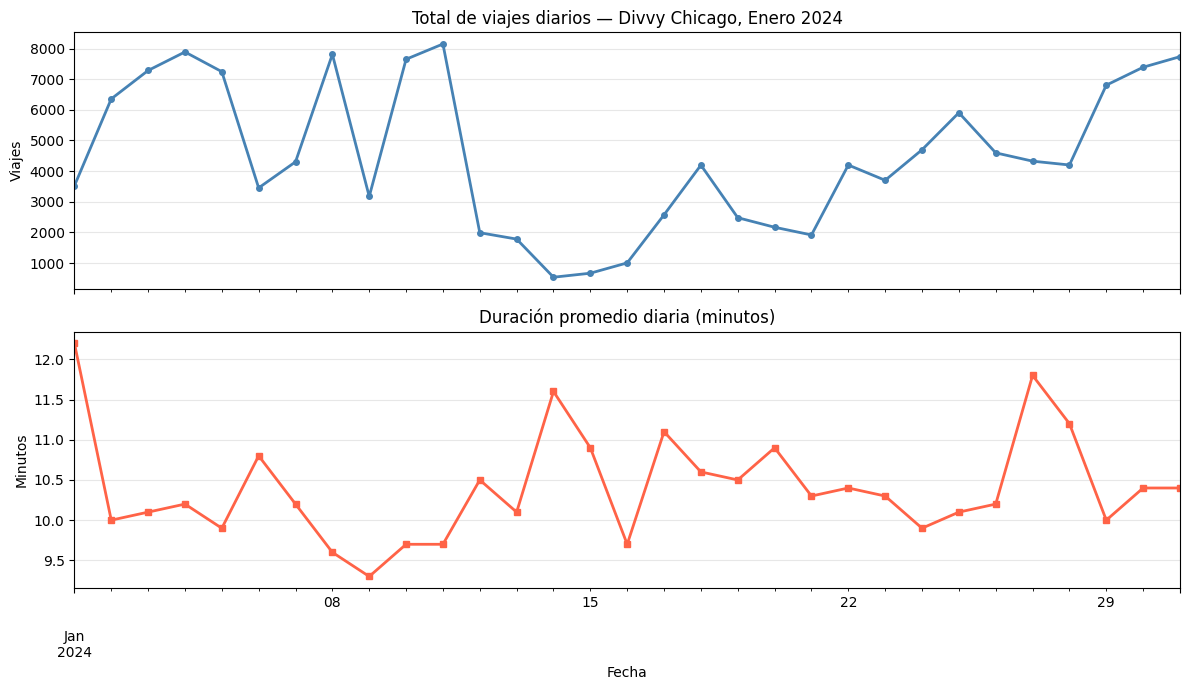

In [15]:
# Visualizar tendencia diaria

# Crea una figura con 2 gráficos apilados verticalmente que comparten el mismo eje X
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

# Grafica la serie del total de viajes en el primer panel (línea azul con círculos)
resumen_diario['total_viajes'].plot(ax=ax1, color='steelblue', linewidth=2, marker='o', markersize=4)
ax1.set_title('Total de viajes diarios — Divvy Chicago, Enero 2024') # Título del primer gráfico
ax1.set_ylabel('Viajes') # Etiqueta del eje Y para el primer gráfico
ax1.grid(alpha=0.3) # Agrega una cuadrícula tenue de fondo

# Grafica la serie de duración promedio en el segundo panel (línea roja con cuadrados)
resumen_diario['duracion_promedio'].plot(ax=ax2, color='tomato', linewidth=2, marker='s', markersize=4)
ax2.set_title('Duración promedio diaria (minutos)') # Título del segundo gráfico
ax2.set_ylabel('Minutos') # Etiqueta del eje Y para el segundo gráfico
ax2.set_xlabel('Fecha') # Etiqueta del eje X compartido
ax2.grid(alpha=0.3) # Agrega una cuadrícula tenue de fondo

# Ajusta el diseño para evitar que los textos se encimen o se corten
plt.tight_layout()

# Despliega los dos gráficos en pantalla
plt.show()

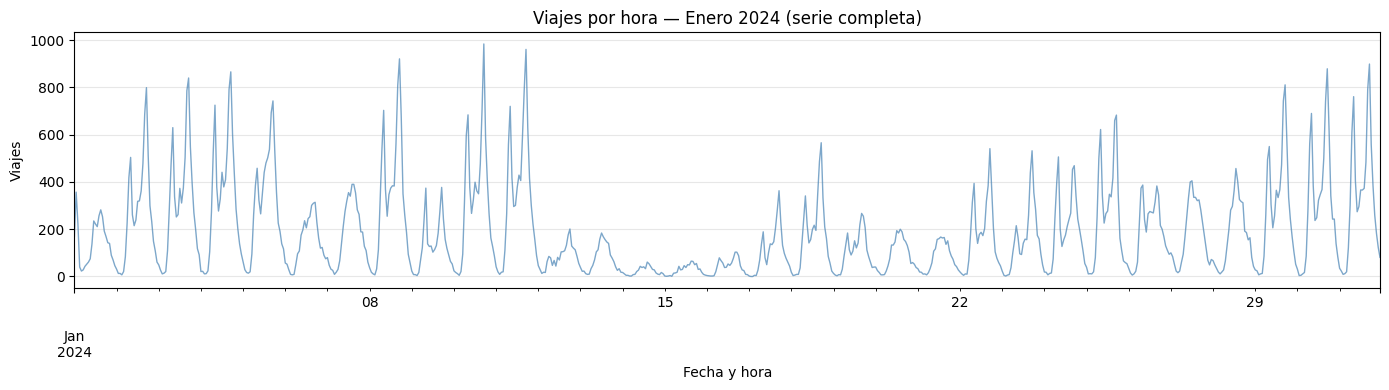

In [16]:
# Resampling por hora: útil para ver patrones intradiarios

# Cambia la frecuencia de los datos para contar la cantidad de viajes por hora
viajes_por_hora_ts = df.resample('h').size()

# Crea el lienzo de la figura y los ejes con un formato ancho (14x4)
fig, ax = plt.subplots(figsize=(14, 4))

# Grafica la serie temporal completa con una línea azul delgada y algo transparente
viajes_por_hora_ts.plot(ax=ax, color='steelblue', alpha=0.7, linewidth=1)

# Configura los títulos principales y las etiquetas correspondientes a cada eje
ax.set_title('Viajes por hora — Enero 2024 (serie completa)')
ax.set_ylabel('Viajes')
ax.set_xlabel('Fecha y hora')

# Añade una cuadrícula de fondo muy suave para facilitar la lectura visual
ax.grid(alpha=0.3)

# Distribuye los elementos de forma óptima para que no se encimen los textos
plt.tight_layout()

# Renderiza y muestra el gráfico final en pantalla
plt.show()

## 8. Resampling segmentado por categoría

Podemos combinar `groupby` con `resample` para obtener tendencias separadas por categoría. Por ejemplo: ¿los usuarios *member* y *casual* tienen patrones temporales distintos?

In [29]:
# Viajes diarios separados por tipo de usuario
viajes_por_tipo = (
    df.groupby('member_casual')     # Agrupa los datos según el tipo de usuario (miembro o casual)
    .resample('D')['ride_id']       # Cambia la frecuencia a base diaria para la columna del ID de viaje
    .count()                        # Cuenta el total de viajes por día para cada categoría
    .unstack(level=0)               # Pasa los tipos de usuario a columnas para facilitar la lectura
)

print("Viajes diarios por tipo de usuario:")
viajes_por_tipo.head()

Viajes diarios por tipo de usuario:


member_casual,casual,member
started_at,,
2024-01-01,1117,2403
2024-01-02,1110,5246
2024-01-03,1294,5989
2024-01-04,1442,6445
2024-01-05,1498,5746


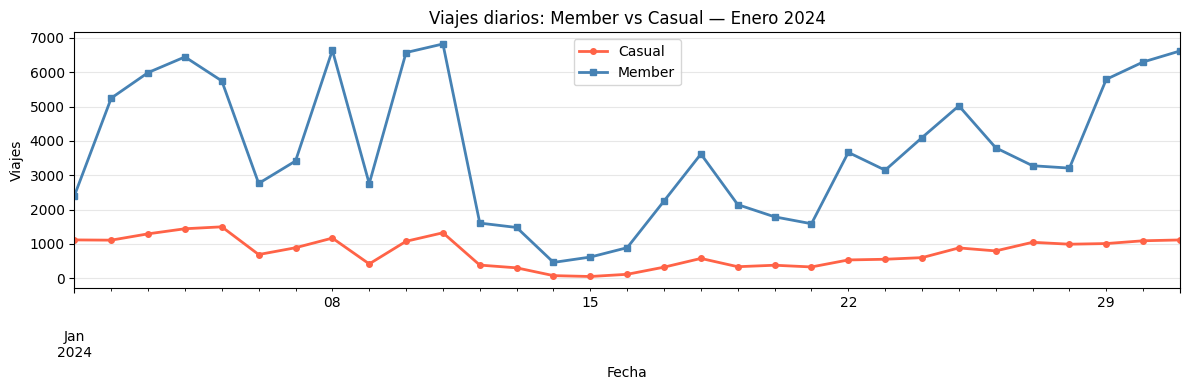

In [ ]:
# Plot de viajes diarios: Member vs Casual

# Inicializa el lienzo del gráfico con un formato ancho (12x4)
fig, ax = plt.subplots(figsize=(12, 4))

# Grafica la serie de usuarios casuales como una línea roja con círculos
viajes_por_tipo['casual'].plot(ax=ax, label='Casual', color='tomato', linewidth=2, marker='o', markersize=4)

# Grafica la serie de miembros registrados como una línea azul con cuadrados
viajes_por_tipo['member'].plot(ax=ax, label='Member', color='steelblue', linewidth=2, marker='s', markersize=4)

# Personaliza el título principal y las etiquetas de los ejes X e Y
ax.set_title('Viajes diarios: Member vs Casual — Enero 2024')
ax.set_ylabel('Viajes')
ax.set_xlabel('Fecha')

# Muestra la leyenda en el gráfico para identificar cada línea por su etiqueta (label)
ax.legend()

# Añade una cuadrícula de fondo muy sutil para facilitar el análisis visual
ax.grid(alpha=0.3)

# Organiza de forma óptima el espacio para evitar que se corten los textos
plt.tight_layout()

# Despliega el gráfico final con ambas líneas superpuestas en la pantalla
plt.show()

## 9. Manejo de zonas horarias (Timezones)

Los datos de Divvy están registrados en hora local de Chicago, pero sin zona horaria explícita (el index no tiene tz). En un sistema de producción que recibe datos de múltiples ciudades, siempre hay que normalizar las zonas horarias.

Chicago usa la zona **America/Chicago** (UTC-6 en invierno, UTC-5 en verano).

- `tz_localize()`: asigna una zona horaria a timestamps que no tienen ninguna.
- `tz_convert()`: convierte de una zona a otra.

Lista de los Time Zone identifiers: https://en.wikipedia.org/wiki/List_of_tz_database_time_zones

In [41]:
# Verificar que el index no tiene zona horaria
print("Zona horaria actual del index:", df.index.tz)

Zona horaria actual del index: None


In [42]:
# Paso 1: Localizar — los datos son de Chicago
df_tz = df.copy()
df_tz.index = df_tz.index.tz_localize('America/Chicago') # Asigna una zona horaria específica (Chicago) al índice de fechas sin modificar la hora local
## aqui se usa el TZ identifier (https://en.wikipedia.org/wiki/List_of_tz_database_time_zones)

print("Zona horaria despues de localizar:", df_tz.index.tz)
print()
print("Primeros 3 timestamps:")
print(df_tz.index[:3])

<DstTzInfo 'America/Chicago' LMT-1 day, 18:09:00 STD>

In [49]:
# Paso 2: Convertir a UTC (estándar para almacenamiento en sistemas distribuidos)
df_utc = df_tz.copy()
df_utc.index = df_utc.index.tz_convert('UTC') # Convierte las fechas de la zona horaria de Chicago a la hora universal coordinada (UTC) con 'tz_convert()'

print("Comparación del mismo viaje en distintas zonas:")
print(f"  Chicago: {df_tz.index[0]}")
print(f"  UTC:     {df_utc.index[0]}")



Timestamp('2024-01-01 06:00:39+0000', tz='UTC')

## 10. Guardar el dataset limpio

Guardamos el dataset procesado para usarlo en la Fase 2. Conservamos las columnas de coordenadas que necesitaremos para el análisis geoespacial.

In [ ]:
# Columnas que conservamos para la Fase 2
columnas_exportar = ['ride_id', 'rideable_type', 'member_casual',
                     'duracion_min', 'hora', 'dia_semana',
                     'start_lat', 'start_lng', 'end_lat', 'end_lng',
                     'start_station_name', 'end_station_name']

df_export = df_tz[columnas_exportar].reset_index()
df_export.to_csv('divvy_enero2024_limpio.csv', index=False)

print(f"Dataset guardado: {len(df_export):,} filas")
print(f"Columnas: {df_export.columns.tolist()}")

---

**Fin de la Fase 1.**  
En la siguiente sesión: Fase 2 — Transformación Geoespacial con GeoPandas usando las coordenadas reales de Divvy.